In [3]:
# Perceptron from Scratch

## Objective

# Implement the original perceptron algorithm from scratch using NumPy for binary classification.

## Topics

# - Data preprocessing
# - Parameter initialization
# - Linear decision boundary
# - Step activation function
# - Perceptron learning rule
# - Prediction
# - Accuracy evaluation

## Architecture

# Input Features
#       |
#       v
# Linear Combination (WX + b)
#       |
#       v
# Step Function
#       |
#       v
# Prediction (0 or 1)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.datasets import make_blobs

In [21]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X / 255.0
    return X

In [22]:
def initialize_parameters(X):
    W = np.random.randn(X.shape[1], 1) * 0.01
    b = 0.0
    return W, b

In [23]:
def model(X, W, b):
    Z = X.dot(W) + b
    return (Z > 0).astype(int)

In [27]:
def perceptron(X_train,y_train,X_test,y_test,lr=0.01,nb_iter=1000):
    W, b = initialize_parameters(X_train)
    train_accs = []
    test_accs = []

    for epoch in tqdm(range(nb_iter)):
        for xi, yi in zip(X_train, y_train):
            xi = xi.reshape(1, -1)
            z = xi.dot(W) + b
            y_pred = 1 if z > 0 else 0
            error = yi - y_pred
            W += lr * error * xi.T
            b += lr * error

        train_pred = predict(X_train, W, b)
        test_pred = predict(X_test, W, b)
        train_accs.append(accuracy_score(y_train, train_pred))
        test_accs.append(accuracy_score(y_test, test_pred))
        
    plt.figure(figsize=(8,5))
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return W, b

In [35]:
def predict(X, W, b):

    Z = X.dot(W) + b

    return (Z > 0).astype(int)

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 350.99it/s]


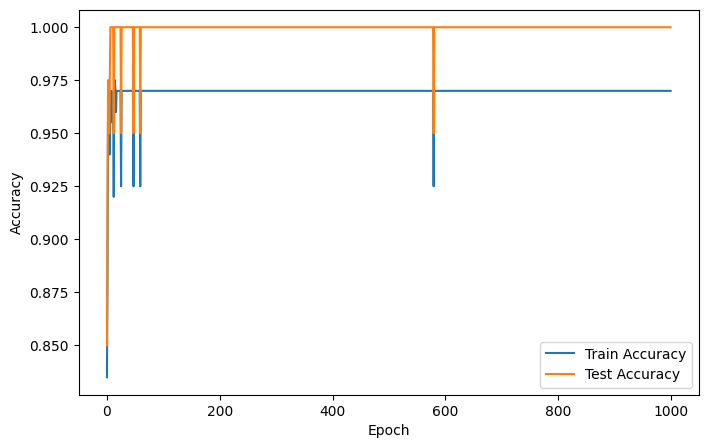

In [36]:
X_train, y_train = make_blobs(n_samples=200, n_features=2, centers=2, random_state=0)
X_test, y_test = make_blobs(n_samples=40, n_features=2, centers=2, random_state=0)

y_train = y_train.reshape((y_train.shape[0], 1))
y_test = y_test.reshape((y_test.shape[0], 1))
W, b = perceptron(X_train, y_train,X_test,y_test,lr=0.001,nb_iter=1000)